In [2]:
import numpy as np
import networkx as nx
import pandas as pd
from tqdm.auto import tqdm
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt


/Users/fritzwuterich/Documents/Uni/Causal_inference/Thesis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generate synthetic data

In [3]:
def generate_dataset_fig3(n, rng):
    nodes_fig3 = ["V1", "V6", "V7", "U1", "U2", "V2", "V3", "X", "V4", "V5", "Y"]
    latent_nodes = ["U1", "U2"]
    observed_nodes = [node for node in nodes_fig3 if node not in latent_nodes]

    B = pd.DataFrame(0, index=nodes_fig3, columns=nodes_fig3, dtype=float)

    B.loc['V1', 'V2'] = rng.uniform(0.5, 1.5)
    B.loc['V1', 'Y']  = rng.uniform(0.5, 1.5)
    B.loc['V1', 'X']  = rng.uniform(0.5, 1.5)
    B.loc['V2', 'Y']  = rng.uniform(0.5, 1.5)
    B.loc['V2', 'X']  = rng.uniform(0.5, 1.5)
    B.loc['V6', 'X']  = rng.uniform(0.5, 1.5)
    B.loc['V6', 'V7'] = rng.uniform(0.5, 1.5)
    B.loc['V4', 'Y']  = rng.uniform(0.5, 1.5)
    B.loc['V4', 'V5'] = rng.uniform(0.5, 1.5)
    B.loc['X', 'Y']   = rng.uniform(0.5, 1.5)
    B.loc['U1', 'V3'] = rng.uniform(0.5, 1.5)
    B.loc['U1', 'X']  = rng.uniform(0.5, 1.5)
    B.loc['U2', 'V3'] = rng.uniform(0.5, 1.5)
    B.loc['U2', 'Y']  = rng.uniform(0.5, 1.5)

    E = pd.DataFrame(
        rng.normal(0, 1, size=(n, len(nodes_fig3))),
        columns=nodes_fig3
    )

    D_full = pd.DataFrame(0, index=np.arange(n), columns=nodes_fig3, dtype=float)

    for node in nodes_fig3:
        parents = B.index[B[node] != 0].tolist()
        if len(parents) == 0:
            D_full[node] = E[node].values
        else:
            D_full[node] = D_full[parents].values @ B.loc[parents, node].values + E[node].values

    D_obs = D_full[observed_nodes].copy()

    B_np = B.loc[nodes_fig3, nodes_fig3].values
    total_effect_matrix = np.linalg.inv(np.eye(len(nodes_fig3)) - B_np) - np.eye(len(nodes_fig3))

    x_idx = nodes_fig3.index("X")
    y_idx = nodes_fig3.index("Y")
    true_ce = total_effect_matrix[x_idx, y_idx]

    return D_obs, B, true_ce

## Helper functions

In [4]:
def build_nx_dag(B):
    G = nx.DiGraph()
    G.add_nodes_from(B.index)
    for parent in B.index:
        for child in B.columns:
            if B.loc[parent, child] != 0:
                G.add_edge(parent, child)
    return G

def ci_oracle(X, Y, Z, G):
    return nx.is_d_separator(G, {X}, {Y}, set(Z))

In [5]:
# run entner rule1 for w , x, y and z 

def r1(w, Z, G, x = 'X', y = 'Y'):
    Z = list(Z)
    Z_plus_x = Z + [x]

    indep1 = ci_oracle(w, y, Z, G)
    indep2 = ci_oracle(w, y, Z_plus_x, G)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R1": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_given_Z": cond_1,
        "cond2_indep_given_Z_plus_x": cond_2
    }

In [6]:
def r2(w, Z, G, x='X', y='Y'):
    Z = list(Z)

    indep1 = ci_oracle(w, x, Z, G)
    indep2 = ci_oracle(w, y, Z, G)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R2": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_w_x_given_Z": cond_1,
        "cond2_indep_w_y_given_Z": cond_2
    }

def r2a(Z, G, x='X', y='Y'):
    return ci_oracle(x, y, Z, G)

In [20]:
def alg_EHS(observed_nodes, G, x='X', y='Y', max_z_size=None):
    W = [col for col in observed_nodes if col not in [x, y]]
    if max_z_size is None:
        max_z_size = len(W)
    
    VASs = []
    R1_count = 0
    R2_count = 0
    CI_num = 0

    # R1 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)
            for w in W:
                if w in Z:
                    continue
                out_r1 = r1(w, Z, G, x, y)
                CI_num += 2

                if out_r1["R1"]:
                    return {
                        'decision': '+',
                        'VASs': Z,
                        'witness_w': w,
                        'CI_num': CI_num
                    }

     # R2 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)
            CI_num += 1
            if r2a(Z, G, x, y):
                return {
                    'decision': '0',
                    'VASs': None,
                    'witness_w': w,
                    'CI_num': CI_num
                }
    

    # R2 ii)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)
            for w in W:
                if w in Z:
                    continue

                out_r2 = r2_oracle(w, Z, G, x=x, y=y)
                CI_num += 2

                if out_r2["R2"]:
                    return {
                        "decision": "0",
                        "VASs": None,
                        "witness_w": w,
                        "CI_num": CI_num
                    }


    return {
        "decision": '?',
        "VASs": None,
        "witness_w": None,
        "CI_num": CI_num
    }

## Run Experiment

In [ ]:
sample_sizes = [1000, 5000, 10000, 15000]
n_reps = 100

results_fig3 = []
structure_name = "figure3"

treatment_fig3 = "X"
outcome_fig3 = "Y"

for n in sample_sizes:
    tqdm.write(f"Running {structure_name} with sample size {n} for {n_reps} reps...")
    for rep in tqdm(range(n_reps), desc=f"Processing {structure_name}", leave=True, position=0):
        D_obs, B, true_ce = generate_dataset_fig3(n, np.random.default_rng(rep))
        G = build_nx_dag(B)
        observed_nodes = D_obs.columns.tolist()
        res = alg_EHS(observed_nodes, G, x=treatment_fig3, y=outcome_fig3, max_z_size=3)

        decision = res["decision"]
        nTest = res["CI_num"]
        VAS = res["VASs"]
        witness_w = res["witness_w"]

        results_fig3.append({
            "structure": structure_name,
            "sample_size": n,
            "rep": rep,
            "decision": decision,
            "nTest": nTest,
            "VASs": str(VASs)
        })


results_fig3 = pd.DataFrame(results_fig3)
results_fig3.head()

Running figure3 with sample size 1000 for 100 reps...


Processing figure3: 100%|██████████| 100/100 [00:00<00:00, 166.15it/s]


Running figure3 with sample size 5000 for 100 reps...


Processing figure3: 100%|██████████| 100/100 [00:00<00:00, 146.18it/s]


Running figure3 with sample size 10000 for 100 reps...


Processing figure3: 100%|██████████| 100/100 [00:00<00:00, 153.26it/s]


Running figure3 with sample size 15000 for 100 reps...


Processing figure3: 100%|██████████| 100/100 [00:00<00:00, 144.00it/s]


,structure,sample_size,rep,decision,nTest,VASs
0,figure3,1000,0,+,120,"['V1', 'V2']"
1,figure3,1000,1,+,120,"['V1', 'V2']"
2,figure3,1000,2,+,120,"['V1', 'V2']"
3,figure3,1000,3,+,120,"['V1', 'V2']"
4,figure3,1000,4,+,120,"['V1', 'V2']"


In [32]:
summary_fig3 = (
    results_fig3
    .groupby("sample_size", as_index=False)
    .agg(
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

summary_fig3

,sample_size,mean_nTest,std_nTest
0,1000,120.0,0.0
1,5000,120.0,0.0
2,10000,120.0,0.0
3,15000,120.0,0.0


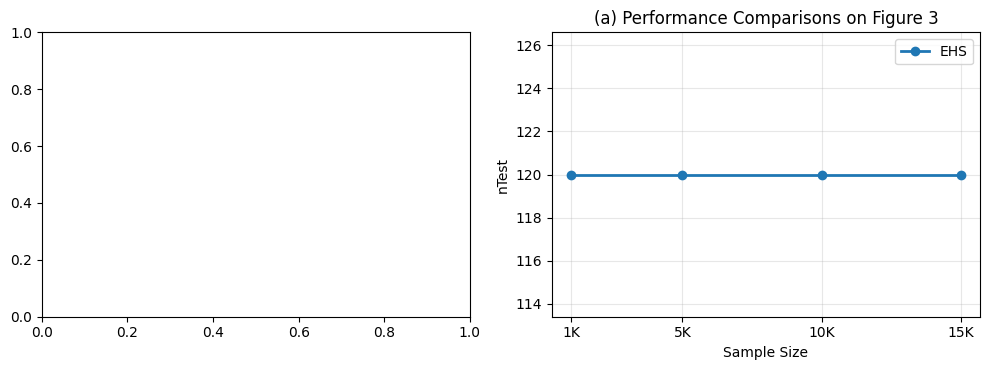

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# nTest panel
axes[1].plot(summary_fig3["sample_size"], summary_fig3["mean_nTest"], marker="o", linewidth=2, label="EHS")
axes[1].set_xlabel("Sample Size")
axes[1].set_ylabel("nTest")
axes[1].set_title("(a) Performance Comparisons on Figure 3")
axes[1].set_xticks(sample_sizes)
axes[1].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()